Eğitim başlıyor, lütfen bekleyin...

--- MODEL SONUÇLARI ---
En İyi Parametre: {'svc__C': 1}
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      7736
           1       0.54      0.16      0.24       792

    accuracy                           0.91      8528
   macro avg       0.73      0.57      0.60      8528
weighted avg       0.88      0.91      0.89      8528



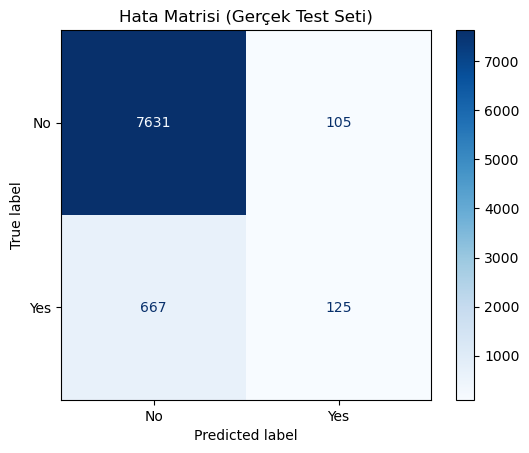

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. VERİ YÜKLEME
df = pd.read_csv('BankCustomerData.csv')

# 2. ÖN İŞLEME (Preprocessing)
# Kategorik verileri sayıya çeviriyoruz (drop_first=True: Gereksiz sütunları atar)
df_encoded = pd.get_dummies(df, columns=['job', 'marital', 'education', 'default', 'housing', 
                                         'loan', 'contact', 'month', 'poutcome'], drop_first=True)

# Hedef değişkeni 1 ve 0 yapıyoruz
df_encoded['term_deposit'] = df_encoded['term_deposit'].map({'yes': 1, 'no': 0})

# 3. VERİ AYIRMA (X ve y)
X = df_encoded.drop('term_deposit', axis=1)
y = df_encoded['term_deposit']

# Büyük sınav setimizi (X_test, y_test) en baştan ayırıyoruz (8528 satır buraya gidecek)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 4. HIZLI EĞİTİM İÇİN ÖRNEKLEM (Sampling)
# Bilgisayarın kilitlenmemesi için sadece eğitim setinden 5000 satır alıyoruz
X_train_sample = X_train_full.sample(n=5000, random_state=42)
y_train_sample = y_train_full.loc[X_train_sample.index] # İndeksleri eşliyoruz ki cevaplar kaymasın

# 5. MODEL VE PIPELINE (Scaling + SVM)
pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('svc', SVC(kernel='linear'))
])

# Parametre listesi
param_grid = {'svc__C': [0.1, 1, 10]}

# Cross-Validation stratejisi
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV Kurulumu
grid_search = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

# 6. BÜYÜK EĞİTİM (5000 Satır Üzerinden)
print("Eğitim başlıyor, lütfen bekleyin...")
grid_search.fit(X_train_sample, y_train_sample)

# 7. TAHMİN VE RAPORLAMA (Gerçek 8528 satır üzerinde!)
y_pred = grid_search.predict(X_test)

print("\n--- MODEL SONUÇLARI ---")
print(f"En İyi Parametre: {grid_search.best_params_}")
print(classification_report(y_test, y_pred))

# 8. HATA MATRİSİ GÖRSELLEŞTİRME
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No', 'Yes'], cmap='Blues')
plt.title('Hata Matrisi (Gerçek Test Seti)')
plt.show()

In [61]:
import joblib

# Eğittiğin en iyi modeli (grid_search içindeki) dosyaya kaydediyoruz
joblib.dump(grid_search.best_estimator_, 'banka_svm_model.pkl')

# Ölçekleyiciyi (scaler) de kaydetmemiz lazım çünkü yeni gelen veriyi de ölçekleyeceğiz
joblib.dump(scaler, 'scaler.pkl')

print("Model ve Ölçekleyici başarıyla kaydedildi! Vitrini kurmaya hazırız.")

Model ve Ölçekleyici başarıyla kaydedildi! Vitrini kurmaya hazırız.
